In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
print("=" * 60)
print("BANK CUSTOMER CHURN PREDICTION MODEL")
print("=" * 60)

BANK CUSTOMER CHURN PREDICTION MODEL


In [4]:
df = pd.read_csv('Churn_Modelling.csv')

print(f"\nDataset Shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

print(f"\nDataset Info:")
print(df.info())

print(f"\nMissing Values:")
print(df.isnull().sum())

print(f"\nChurn Distribution:")
print(df['Exited'].value_counts())
print(f"\nChurn Rate: {df['Exited'].mean() * 100:.2f}%")


Dataset Shape: (10000, 14)

First few rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1

In [5]:
print("\n" + "=" * 60)
print("DATA PREPROCESSING")
print("=" * 60)

# Drop irrelevant columns
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode categorical variables
le_geography = LabelEncoder()
le_gender = LabelEncoder()

df_clean['Geography'] = le_geography.fit_transform(df_clean['Geography'])
df_clean['Gender'] = le_gender.fit_transform(df_clean['Gender'])

print(f"\nEncoded Features:")
print(f"Geography mapping: {dict(zip(le_geography.classes_, le_geography.transform(le_geography.classes_)))}")
print(f"Gender mapping: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")


DATA PREPROCESSING

Encoded Features:
Geography mapping: {'France': np.int64(0), 'Germany': np.int64(1), 'Spain': np.int64(2)}
Gender mapping: {'Female': np.int64(0), 'Male': np.int64(1)}


In [6]:
print("\n" + "=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Statistical summary
print("\nStatistical Summary:")
print(df_clean.describe())



EXPLORATORY DATA ANALYSIS

Statistical Summary:
        CreditScore     Geography        Gender           Age        Tenure  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean     650.528800      0.746300      0.545700     38.921800      5.012800   
std       96.653299      0.827529      0.497932     10.487806      2.892174   
min      350.000000      0.000000      0.000000     18.000000      0.000000   
25%      584.000000      0.000000      0.000000     32.000000      3.000000   
50%      652.000000      0.000000      1.000000     37.000000      5.000000   
75%      718.000000      1.000000      1.000000     44.000000      7.000000   
max      850.000000      2.000000      1.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.405202       0.581654


✓ Correlation heatmap saved as 'correlation_heatmap.png'


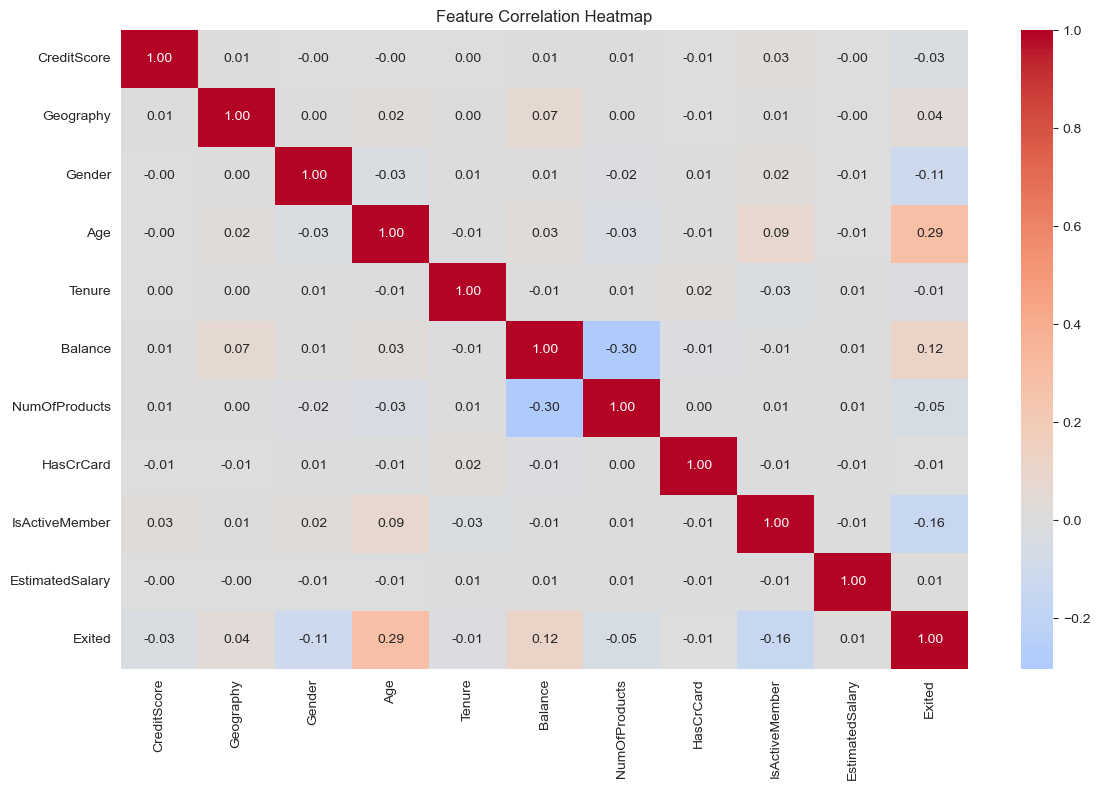

In [7]:
plt.figure(figsize=(12, 8))
corr_matrix = df_clean.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("\n✓ Correlation heatmap saved as 'correlation_heatmap.png'")

✓ Churn analysis saved as 'churn_analysis.png'


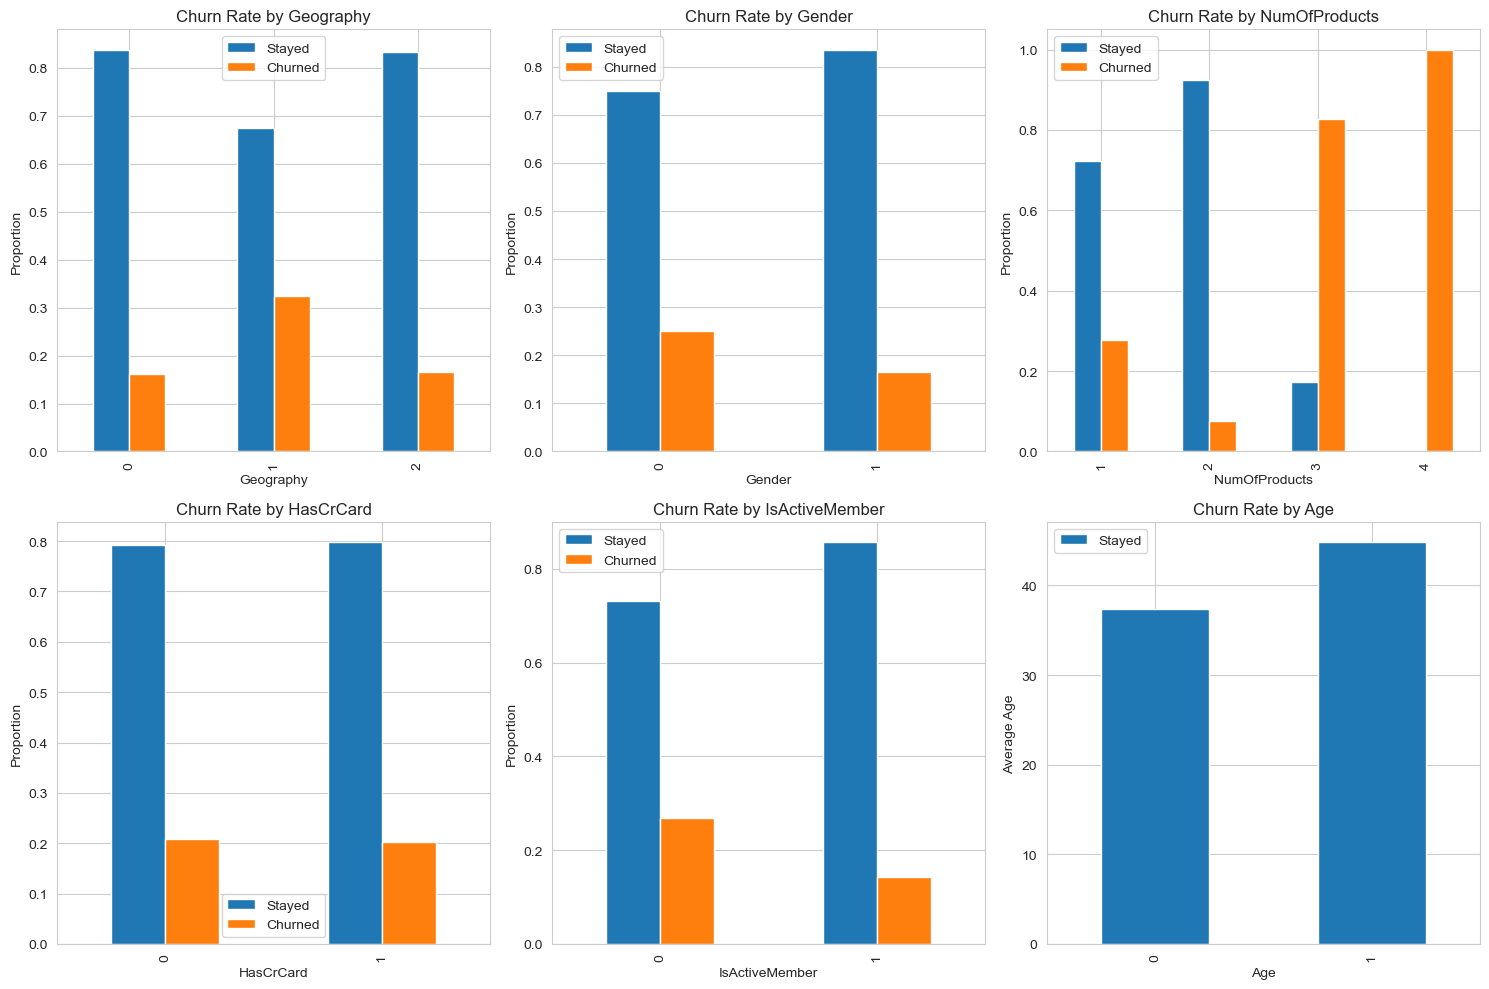

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Age']

for idx, feature in enumerate(features):
    ax = axes[idx // 3, idx % 3]
    if feature in ['Age']:
        df_clean.groupby('Exited')[feature].mean().plot(kind='bar', ax=ax)
        ax.set_ylabel('Average Age')
    else:
        pd.crosstab(df_clean[feature], df_clean['Exited'], normalize='index').plot(kind='bar', ax=ax)
        ax.set_ylabel('Proportion')
    ax.set_title(f'Churn Rate by {feature}')
    ax.legend(['Stayed', 'Churned'])
    ax.set_xlabel(feature)

plt.tight_layout()
plt.savefig('churn_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Churn analysis saved as 'churn_analysis.png'")

In [9]:
print("\n" + "=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# Create additional features
df_clean['BalanceSalaryRatio'] = df_clean['Balance'] / (df_clean['EstimatedSalary'] + 1)
df_clean['TenureAgeRatio'] = df_clean['Tenure'] / (df_clean['Age'] + 1)
df_clean['ProductsPerYear'] = df_clean['NumOfProducts'] / (df_clean['Tenure'] + 1)

print("✓ Created new features: BalanceSalaryRatio, TenureAgeRatio, ProductsPerYear")


FEATURE ENGINEERING
✓ Created new features: BalanceSalaryRatio, TenureAgeRatio, ProductsPerYear


In [10]:
print("\n" + "=" * 60)
print("MODEL PREPARATION")
print("=" * 60)

# Split features and target
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features standardized")


MODEL PREPARATION

Training set size: 8000
Test set size: 2000
✓ Features standardized


In [11]:
print("\n" + "=" * 60)
print("MODEL TRAINING & EVALUATION")
print("=" * 60)

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100)
}

results = {}

for name, model in models.items():
    print(f"\n{'-' * 60}")
    print(f"Training {name}...")
    print(f"{'-' * 60}")
    
    # Train model
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))
    
    print(f"\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    
    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'confusion_matrix': cm
    }


MODEL TRAINING & EVALUATION

------------------------------------------------------------
Training Logistic Regression...
------------------------------------------------------------

Accuracy: 0.8055
ROC-AUC Score: 0.7706

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.82      0.97      0.89      1593
     Churned       0.59      0.15      0.24       407

    accuracy                           0.81      2000
   macro avg       0.70      0.56      0.56      2000
weighted avg       0.77      0.81      0.76      2000


Confusion Matrix:
[[1550   43]
 [ 346   61]]

------------------------------------------------------------
Training Random Forest...
------------------------------------------------------------

Accuracy: 0.8650
ROC-AUC Score: 0.8465

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
     Churned       0.79      0.46      0.58       407

  

In [12]:
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'ROC-AUC': [results[m]['roc_auc'] for m in results.keys()]
})

print("\n", comparison_df.to_string(index=False))

# Find best model
best_model_name = comparison_df.loc[comparison_df['ROC-AUC'].idxmax(), 'Model']
print(f"\n🏆 Best Model: {best_model_name}")


MODEL COMPARISON

               Model  Accuracy  ROC-AUC
Logistic Regression    0.8055 0.770559
      Random Forest    0.8650 0.846533
  Gradient Boosting    0.8680 0.866106

🏆 Best Model: Gradient Boosting



GENERATING VISUALIZATIONS
✓ ROC curves saved as 'roc_curves.png'
✓ Confusion matrices saved as 'confusion_matrices.png'
✓ Feature importance saved as 'feature_importance.png'


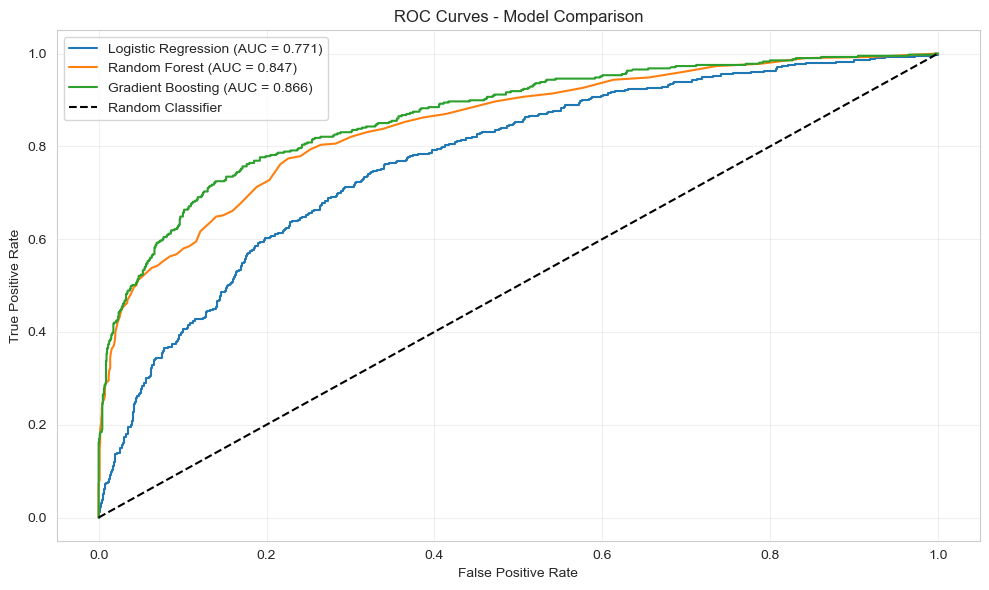

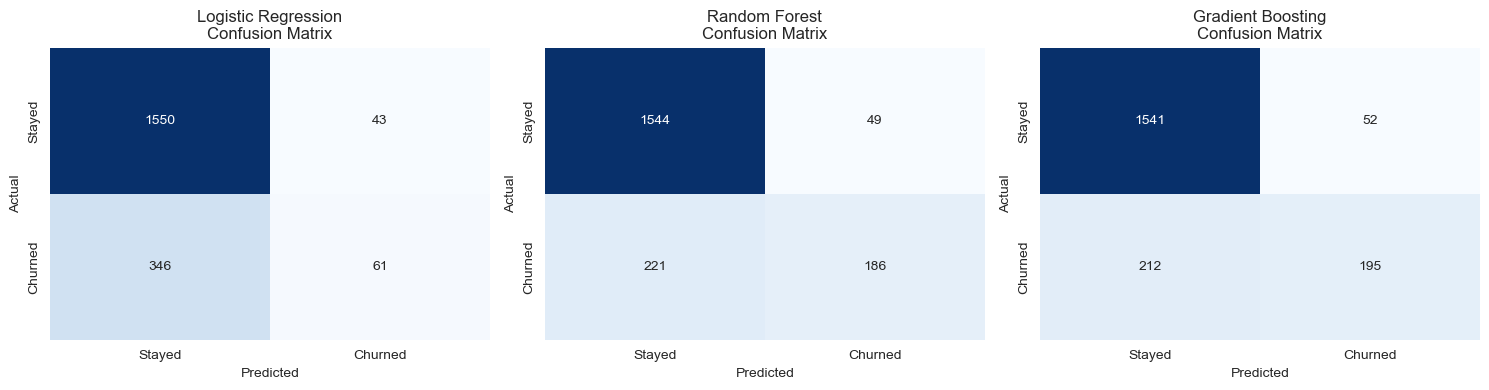

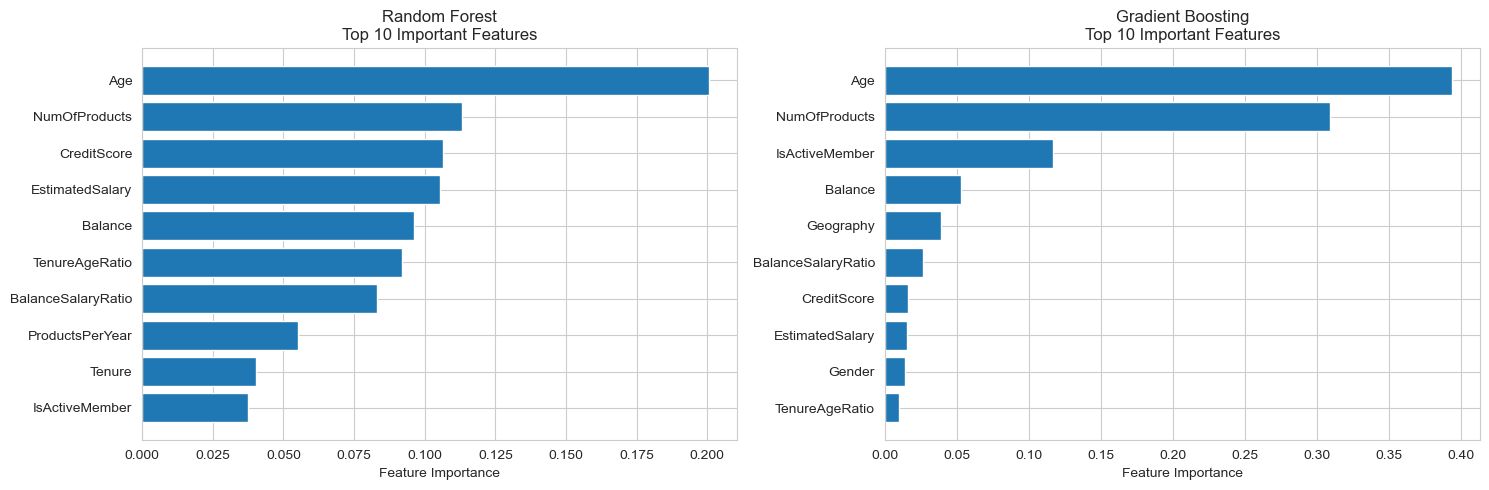

In [13]:
print("\n" + "=" * 60)
print("GENERATING VISUALIZATIONS")
print("=" * 60)

# ROC Curves
plt.figure(figsize=(10, 6))
for name in results.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_pred_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
print("✓ ROC curves saved as 'roc_curves.png'")

# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (name, result) in enumerate(results.items()):
    sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', cmap='Blues', 
                ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_xticklabels(['Stayed', 'Churned'])
    axes[idx].set_yticklabels(['Stayed', 'Churned'])

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
print("✓ Confusion matrices saved as 'confusion_matrices.png'")

# Feature Importance (for tree-based models)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
tree_models = ['Random Forest', 'Gradient Boosting']

for idx, name in enumerate(tree_models):
    importances = results[name]['model'].feature_importances_
    indices = np.argsort(importances)[::-1][:10]
    
    axes[idx].barh(range(10), importances[indices])
    axes[idx].set_yticks(range(10))
    axes[idx].set_yticklabels([X.columns[i] for i in indices])
    axes[idx].set_xlabel('Feature Importance')
    axes[idx].set_title(f'{name}\nTop 10 Important Features')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("✓ Feature importance saved as 'feature_importance.png'")


In [14]:
print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING (Best Model)")
print("=" * 60)

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
    best_model = RandomForestClassifier(random_state=42)
    X_train_final = X_train
    X_test_final = X_test
    
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5],
        'min_samples_split': [2, 5]
    }
    best_model = GradientBoostingClassifier(random_state=42)
    X_train_final = X_train
    X_test_final = X_test
    
else:  # Logistic Regression
    param_grid = {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear']
    }
    best_model = LogisticRegression(random_state=42, max_iter=1000)
    X_train_final = X_train_scaled
    X_test_final = X_test_scaled

print(f"\nTuning {best_model_name}...")
grid_search = GridSearchCV(best_model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_final, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}")

# Final evaluation
final_predictions = grid_search.predict(X_test_final)
final_proba = grid_search.predict_proba(X_test_final)[:, 1]

print(f"\nFinal Test Accuracy: {accuracy_score(y_test, final_predictions):.4f}")
print(f"Final Test ROC-AUC: {roc_auc_score(y_test, final_proba):.4f}")

print("\n" + "=" * 60)
print("MODEL TRAINING COMPLETE!")
print("=" * 60)
print("\nGenerated Files:")
print("  • correlation_heatmap.png")
print("  • churn_analysis.png")
print("  • roc_curves.png")
print("  • confusion_matrices.png")
print("  • feature_importance.png")
print("\nNext Steps:")
print("  1. Review feature importance to understand key churn drivers")
print("  2. Use the tuned model for predictions on new customers")
print("  3. Implement retention strategies based on high-risk segments")
print("=" * 60)


HYPERPARAMETER TUNING (Best Model)

Tuning Gradient Boosting...

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation ROC-AUC: 0.8614

Final Test Accuracy: 0.8680
Final Test ROC-AUC: 0.8661

MODEL TRAINING COMPLETE!

Generated Files:
  • correlation_heatmap.png
  • churn_analysis.png
  • roc_curves.png
  • confusion_matrices.png
  • feature_importance.png

Next Steps:
  1. Review feature importance to understand key churn drivers
  2. Use the tuned model for predictions on new customers
  3. Implement retention strategies based on high-risk segments
